<a href="https://colab.research.google.com/github/serovkins/Lab-1/blob/main/exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 1. Инициализация среды. Загрузка и осмотр данных

## Шаг 0. Настройка среды выполнения
Если вы выполняете задание на локальной машине, перед выполнением задания создайте виртуальную среду, активируйте её и установите библиотеки `pandas`, `numpy`, `matplotlib` и `seaborn`.  

Если вы выполняете задание в Colab или Kaggle, активируйте среду выполнения.

## Шаг 0.1. Импорт библиотек
Выполните ячейку ниже, чтобы импортировать все необходимые для работы библиотеки.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Шаг 1. Определение номера варианта и скачивание датасета
Перейдите в Google Таблицу со списком студентов. Найдите своё ФИО и запомните порядковый номер (поле № п/п) в первом столбце. Заполните его в ячейке ниже и выполните ячейку. Если вы не можете найти себя в списке — обратитесь к преподавателю.


In [54]:
Student_ID = 22

Теперь выполните следующую ячейку. Она вычислит номер варианта и выведет ссылку на датасет.

In [55]:
datasets = [
    ('US Air Carrier Market 2019',
     'https://raw.githubusercontent.com/markpolyak/datasets/refs/heads/main/data/aircarrier_market_us_2019.zip'),
    ('Video Game Sales with Ratings',
     'https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings'),
    ('Titanic',
     'https://www.kaggle.com/datasets/yasserh/titanic-dataset'),
    ('Adult Income (Census Income)',
     'https://www.kaggle.com/datasets/uciml/adult-census-income'),
    ('Spotify Tracks Dataset',
     'https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset'),
    ('Melbourne Housing Market',
     'https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market'),
    ('NYC Airbnb Listings',
     'https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data'),
    ('Airline Passenger Satisfaction',
     'https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction'),
]

dataset_id = None if Student_ID is None else (Student_ID - 1) % len(datasets)
if dataset_id is None:
    print("ОШИБКА! Не указан Student_ID")
else:
    print(f"Ваш датасет № {dataset_id + 1}: {datasets[dataset_id][0]}")
    print(f"Ссылка: {datasets[dataset_id][1]}")
    print(f"Подробности в файле datasets_info.md")

Ваш датасет № 6: Melbourne Housing Market
Ссылка: https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market
Подробности в файле datasets_info.md


**Скачайте датасет.** Если вам дана ссылка на файл (`.csv`, `.zip`, `.tsv` и т.д.), скачайте его с помощью команды `!wget <dataset_url>` или `curl ...`. При необходимости разархивируйте датасет командами `!unzip`, `!tar` и др.

Если вам дана ссылка на kaggle.com, перейдите по ней и скачайте датасет кнопкой Download. В раскрывающемся списке «Download via» выберите cUrl и скопируйте готовую команду в ячейку ниже.

**Примечание**: в Jupyter-ноутбуке можно использовать команды bash, поставив в начале ячейки `!`.

In [56]:
!curl -L -o melbourne-housing-market.zip https://www.kaggle.com/api/v1/datasets/download/anthonypino/melbourne-housing-market
!unzip -o melbourne-housing-market.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2332k  100 2332k    0     0  2069k      0  0:00:01  0:00:01 --:--:-- 2069k
Archive:  melbourne-housing-market.zip
  inflating: MELBOURNE_HOUSE_PRICES_LESS.csv  
  inflating: Melbourne_housing_FULL.csv  


In [57]:
!ls

MELBOURNE_HOUSE_PRICES_LESS.csv  melbourne-housing-market.zip
Melbourne_housing_FULL.csv	 sample_data


## Шаг 2. Загрузка данных


Загрузите датасет в `pandas.DataFrame`, сохраните его в переменной `df`. Проинспектируйте датасет, используя `df.head()`.

In [58]:
### BEGIN YOUR CODE
df = pd.read_csv("Melbourne_housing_FULL.csv")

### END YOUR CODE

In [59]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [60]:
df.shape

(34857, 21)

In [61]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

Сконвертируйте названия столбцов в нижний регистр, после этого создайте переменную `columns` и сохраните в неё список столбцов.

In [62]:
### BEGIN YOUR CODE
df.columns = df.columns.str.lower()
columns = df.columns.tolist()
### END YOUR CODE

print(columns)

['suburb', 'address', 'rooms', 'type', 'price', 'method', 'sellerg', 'date', 'distance', 'postcode', 'bedroom2', 'bathroom', 'car', 'landsize', 'buildingarea', 'yearbuilt', 'councilarea', 'lattitude', 'longtitude', 'regionname', 'propertycount']


Выведите информацию о датафрейме с помощью функции `.info()`. Обратите внимание на типы столбцов и количество непустых значений в каждом из них.

In [63]:
### BEGIN YOUR CODE
df.info()
### END YOUR CODE

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   suburb         34857 non-null  object 
 1   address        34857 non-null  object 
 2   rooms          34857 non-null  int64  
 3   type           34857 non-null  object 
 4   price          27247 non-null  float64
 5   method         34857 non-null  object 
 6   sellerg        34857 non-null  object 
 7   date           34857 non-null  object 
 8   distance       34856 non-null  float64
 9   postcode       34856 non-null  float64
 10  bedroom2       26640 non-null  float64
 11  bathroom       26631 non-null  float64
 12  car            26129 non-null  float64
 13  landsize       23047 non-null  float64
 14  buildingarea   13742 non-null  float64
 15  yearbuilt      15551 non-null  float64
 16  councilarea    34854 non-null  object 
 17  lattitude      26881 non-null  float64
 18  longti

## Шаг 3. Анализ датафрейма


Проверьте, есть ли в данном датасете пропущенные значения? Удалите из датафрейма **строки** с пропущенными значениями.

**ВАЖНО**: не перезаписывайте исходную переменную `df`, вместо этого сохраните новый датафрейм в переменную `df_dropna`.

In [64]:
### BEGIN YOUR CODE

df_dropna = df.dropna().copy()
### END YOUR CODE

In [65]:
df_dropna.shape

(8887, 21)

In [66]:
df_dropna.isnull().sum()

,0
suburb,0
address,0
rooms,0
type,0
price,0
method,0
sellerg,0
date,0
distance,0
postcode,0


Сгенерируйте сводную статистику по вашему датасету с помощью встроенной функции `.describe()`.

In [67]:
### BEGIN YOUR CODE
df_dropna.describe()
### END YOUR CODE

,rooms,price,distance,postcode,bedroom2,bathroom,car,landsize,buildingarea,yearbuilt,lattitude,longtitude,propertycount
count,8887.000000,8.887000e+03,8887.000000,8887.000000,8887.000000,8887.000000,8887.000000,8887.000000,8887.000000,8887.000000,8887.000000,8887.000000,8887.000000
mean,3.098909,1.092902e+06,11.199887,3111.662653,3.078204,1.646450,1.692247,523.480365,149.309477,1965.753348,-37.804501,144.991393,7475.940137
std,0.963786,6.793819e+05,6.813402,112.614268,0.966269,0.721611,0.975464,1061.324228,87.925580,37.040876,0.090549,0.118919,4375.024364
min,1.000000,1.310000e+05,0.000000,3000.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1196.000000,-38.174360,144.423790,249.000000
25%,2.000000,6.410000e+05,6.400000,3044.000000,2.000000,1.000000,1.000000,212.000000,100.000000,1945.000000,-37.858560,144.920000,4382.500000
50%,3.000000,9.000000e+05,10.200000,3084.000000,3.000000,2.000000,2.000000,478.000000,132.000000,1970.000000,-37.798700,144.998500,6567.000000
75%,4.000000,1.345000e+06,13.900000,3150.000000,4.000000,2.000000,2.000000,652.000000,180.000000,2000.000000,-37.748945,145.064560,10331.000000
max,12.000000,9.000000e+06,47.400000,3977.000000,12.000000,9.000000,10.000000,42800.000000,3112.000000,2019.000000,-37.407200,145.526350,21650.000000


**Вопрос для размышления.** Ответьте на следующие вопросы, записав ответы в переменные ниже:

- `reflection_1_missing` — какова доля пропущенных значений в датасете (в % от общего числа ячеек)? Считаете ли вы эту долю значительной? Почему?
- `reflection_1_mean_median` — для каких числовых признаков среднее и медиана сильно расходятся? Что это говорит о форме распределения?

In [68]:
### BEGIN YOUR CODE
reflection_1_missing = ("После удаления всех строк, содержащих хотя бы один пропуск, количество объектов уменьшилось с 34857 до 8887, то есть было удалено около 74.5% строк, я считаю эту потерю значительной, потому что утратилось большое кол-во существенных данных.")
reflection_1_mean_median = ("Например, средняя цена недвижимости составляет примерно 1.09 миллиона, а медианная цена равна 900 тысячам. Это говорит об асимметрии распределения и наличии дорогих объектов, которые увеличивают среднее значение. ")
### END YOUR CODE

### Дополнительное задание *. Заполните пропуски в датасете

**ВАЖНО**: не является обязательным, но даёт дополнительные баллы.

Для заполнения пропусков используйте моду для категориальных признаков и медиану для числовых. Сохраните результат в переменную `df_fillna`.

In [69]:
### BEGIN YOUR CODE
df_fillna = df.copy()

for col in df_fillna.columns:
    if pd.api.types.is_numeric_dtype(df_fillna[col]):
        df_fillna[col] = df_fillna[col].fillna(df_fillna[col].median())
    else:
        df_fillna[col] = df_fillna[col].fillna(df_fillna[col].mode()[0])
### END YOUR CODE

In [70]:
df_fillna.isnull().sum()

,0
suburb,0
address,0
rooms,0
type,0
price,0
method,0
sellerg,0
date,0
distance,0
postcode,0


In [71]:
df_fillna.shape

(34857, 21)

# Задание 2. Работа с числовыми признаками

## Шаг 1. Отбор числовых признаков

Определите числовые признаки датасета. Запишите их названия в список `numeric_features`. После этого отделите от датафрейма `df_dropna` часть со всеми числовыми признаками.

**Примечание**: ориентируйтесь на смысл признака, а не только на тип в pandas — например, год выпуска может храниться как `int`, но по смыслу быть категориальным. В таких случаях принимайте решение самостоятельно.

**ВАЖНО**: не перезаписывайте `df_dropna`, запишите результат в переменную `df_numeric`.


In [72]:
### BEGIN YOUR CODE
numeric_features = [
    "rooms",
    "price",
    "distance",
    "bedroom2",
    "bathroom",
    "car",
    "landsize",
    "buildingarea",
    "yearbuilt",
    "propertycount"
]

df_numeric = df_dropna[numeric_features].copy()
### END YOUR CODE

In [73]:
df_numeric.head()

,rooms,price,distance,bedroom2,bathroom,car,landsize,buildingarea,yearbuilt,propertycount
2,2,1035000.0,2.5,2.0,1.0,0.0,156.0,79.0,1900.0,4019.0
4,3,1465000.0,2.5,3.0,2.0,0.0,134.0,150.0,1900.0,4019.0
6,4,1600000.0,2.5,3.0,1.0,2.0,120.0,142.0,2014.0,4019.0
11,3,1876000.0,2.5,4.0,2.0,0.0,245.0,210.0,1910.0,4019.0
14,2,1636000.0,2.5,2.0,1.0,2.0,256.0,107.0,1890.0,4019.0


In [74]:
df_numeric.shape

(8887, 10)

## Шаг 2. Визуализация распределений

Для каждого числового признака визуализируйте его распределение, используя гистограммы. Поместите название признака в заголовок. Сохраните объект Figure в переменную `fig_numeric_distributions`.

Подсказка: используйте `plt.subplots` для размещения нескольких графиков на одной фигуре.

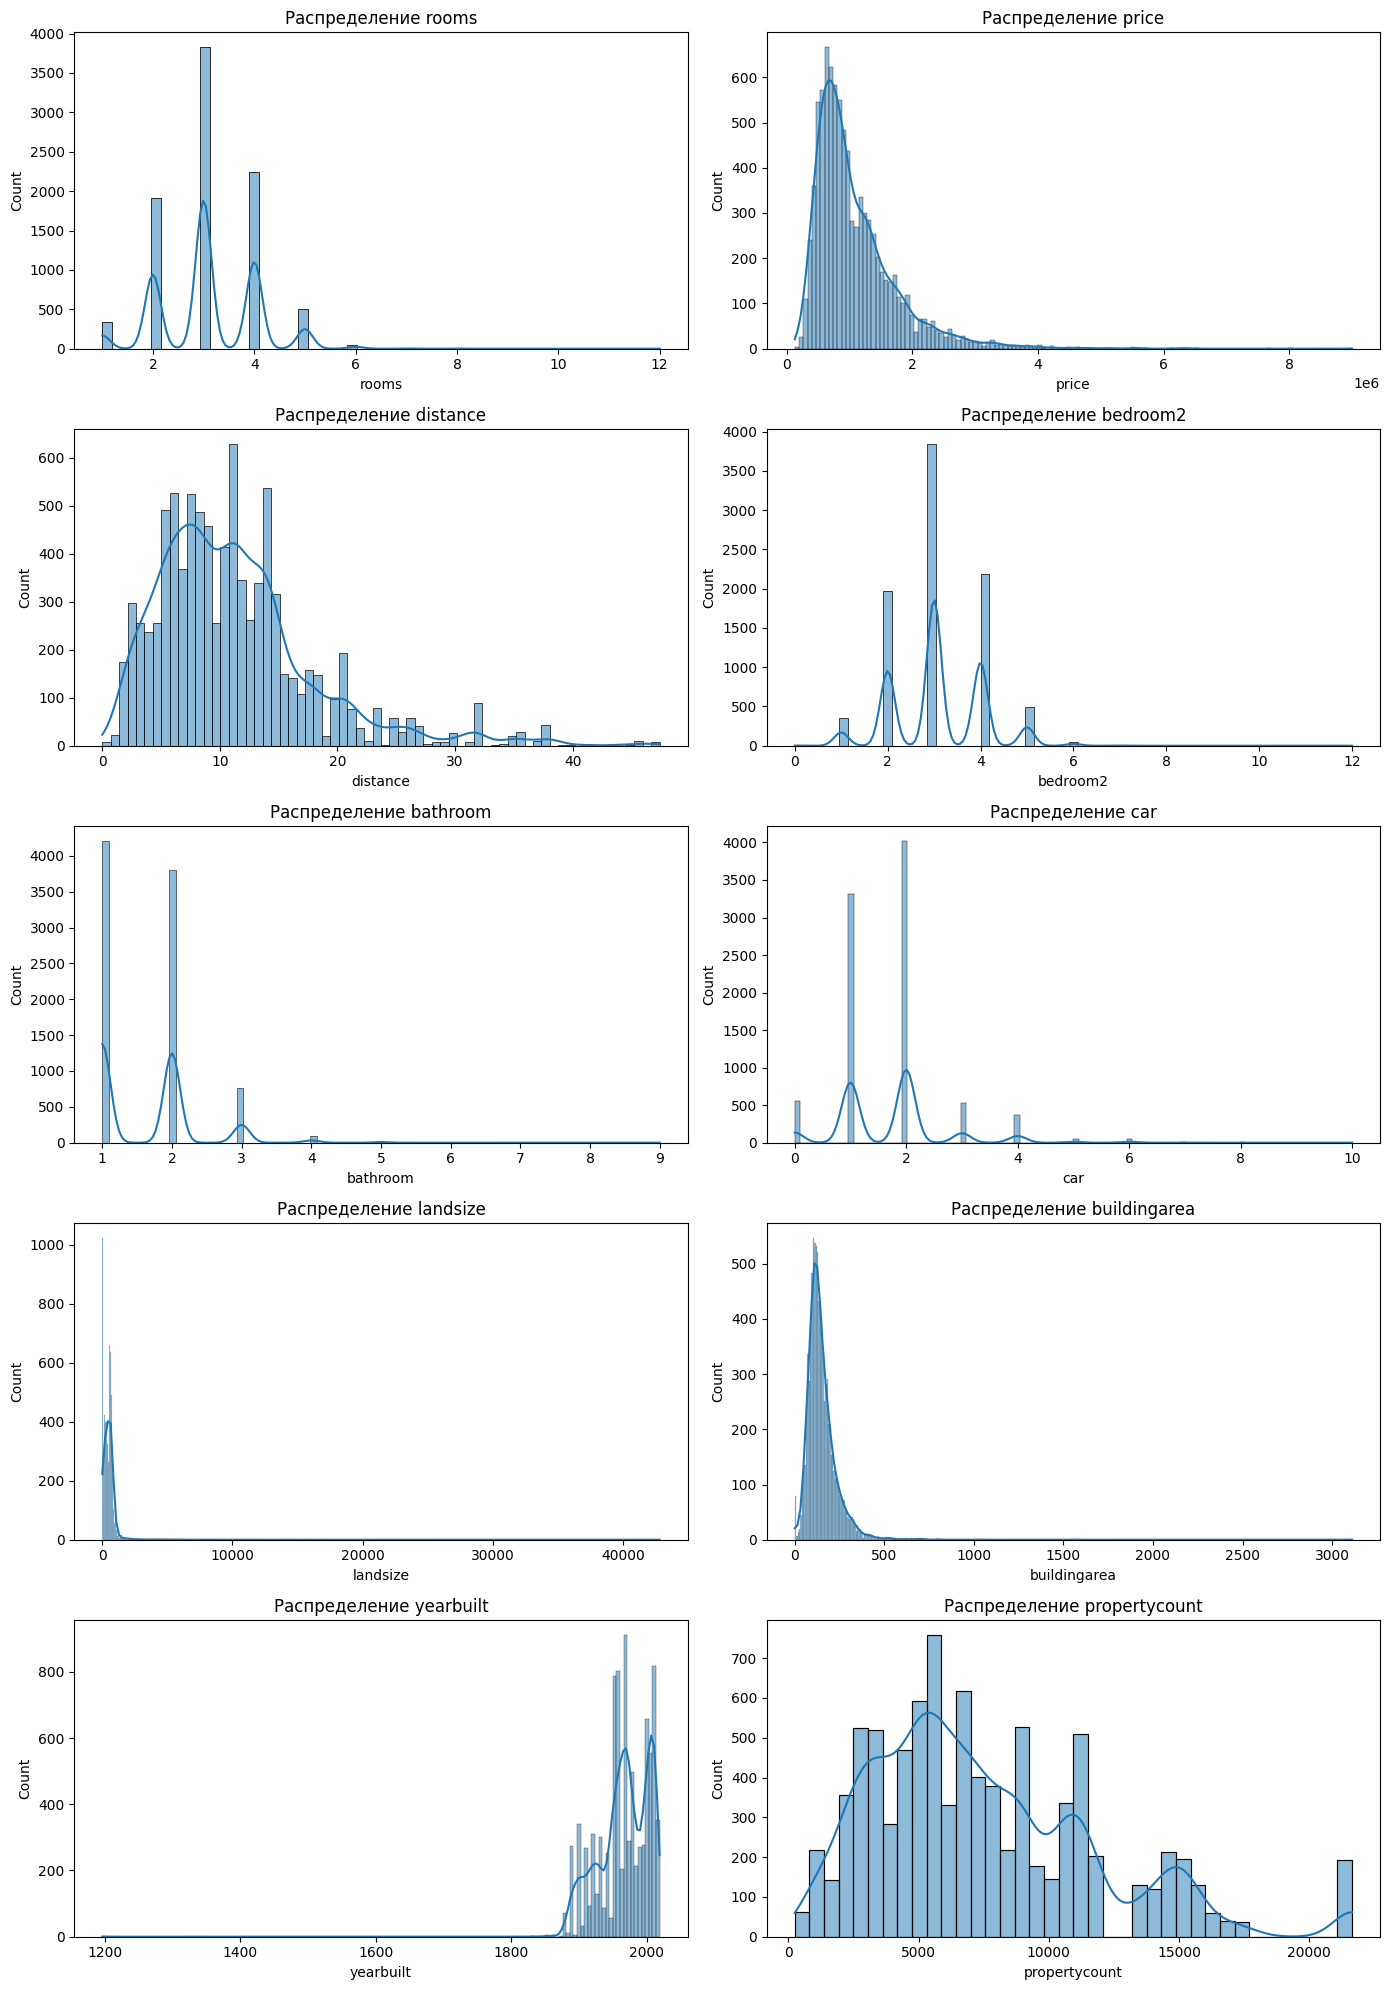

In [75]:
### BEGIN YOUR CODE
fig_numeric_distributions, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(14, 20)
)

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(
        data=df_numeric,
        x=feature,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Распределение {feature}")

plt.tight_layout()
### END YOUR CODE

**Вопрос для размышления.** Запишите ответ в переменную `reflection_2_distributions`:

Опишите форму распределения для каждого числового признака: симметричное или скошенное, унимодальное или мультимодальное? Есть ли очевидные выбросы, заметные на гистограмме?

In [76]:
### BEGIN YOUR CODE
reflection_2_distributions =(
    "Распределения числовых признаков заметно различаются.Признаки rooms, bedroom2, bathroom и car имеют дискретный характер и сосредоточены около нескольких наиболее частых значений. Распределения price, distance, landsize, buildingarea и propertycount скошены вправо и имеют длинные правые хвосты. Для landsize и buildingarea заметны особенно крупные значения, которые могут рассматриваться как потенциальные выбросы. Распределение yearbuilt отличается от остальных и может иметь несколько пиков, что связано с разными периодами строительства недвижимости.")
### END YOUR CODE

## Шаг 3. Поиск корреляции между числовыми признаками

Вычислите корреляции по Пирсону и по Спирмену между всеми парами числовых признаков. Сохраните матрицы корреляций в переменные `corr_pearson` и `corr_spearman` соответственно.

Подсказка: используйте метод `df_numeric.corr(method=...)`. Документация: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html

In [77]:
### BEGIN YOUR CODE
corr_pearson = df_numeric.corr(method="pearson")
corr_spearman = df_numeric.corr(method="spearman")

### END YOUR CODE

Для корреляций по Пирсону постройте тепловую карту от −1 до 1, с центром в 0. Укажите названия признаков для строк и столбцов. Сохраните Figure в переменную `fig_heatmap_pearson`.

Подсказка: используйте `seaborn.heatmap()`.

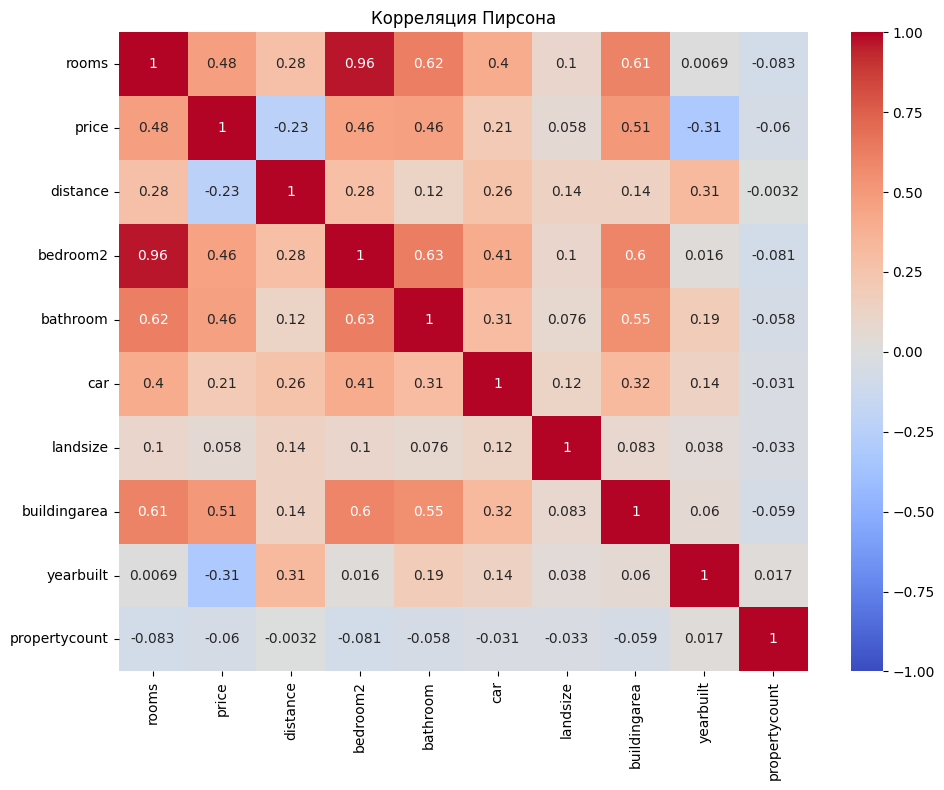

In [78]:
### BEGIN YOUR CODE
fig_heatmap_pearson, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_pearson,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    ax=ax
)

ax.set_title("Корреляция Пирсона")
plt.tight_layout()
### END YOUR CODE

Аналогично для корреляций по Спирмену. Сохраните Figure в переменную `fig_heatmap_spearman`.

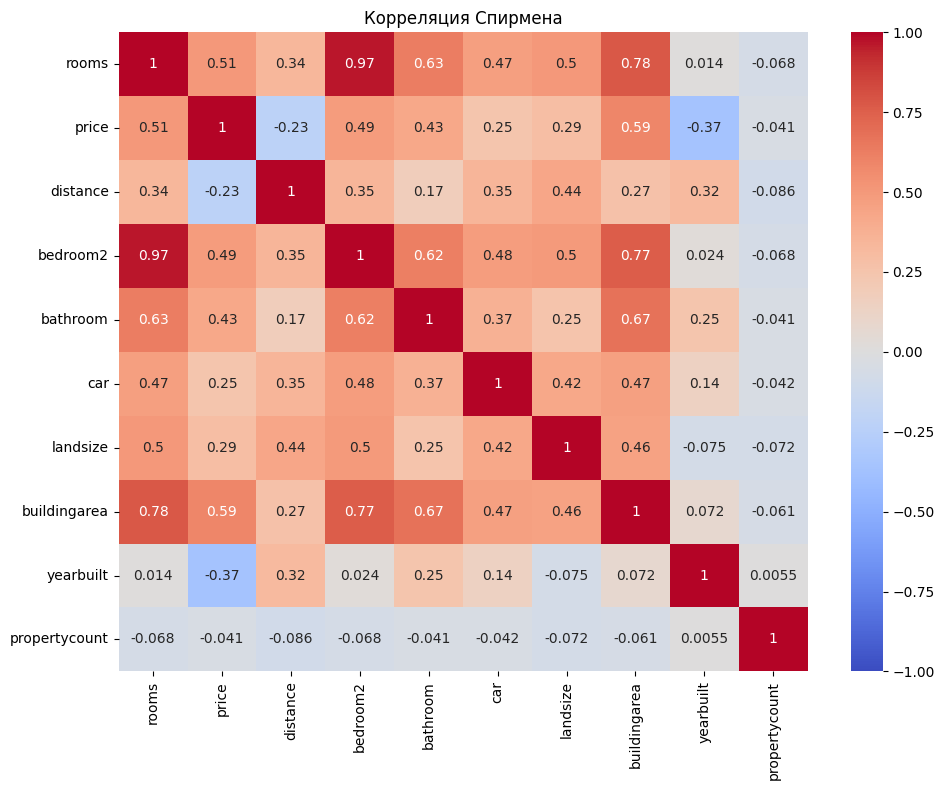

In [79]:
### BEGIN YOUR CODE
fig_heatmap_spearman, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    ax=ax
)

ax.set_title("Корреляция Спирмена")
plt.tight_layout()
### END YOUR CODE

**Вопрос для размышления.** Запишите ответы в переменные ниже:

- `reflection_3_pearson` — какая пара признаков имеет наибольшую корреляцию по Пирсону? Как вы интерпретируете эту связь содержательно?
- `reflection_3_difference` — есть ли пары признаков, у которых корреляция по Пирсону и по Спирмену заметно отличается? Как вы думаете, с чем это связано?

In [80]:
### BEGIN YOUR CODE
reflection_3_pearson = ("По матрице корреляции Пирсона наиболее заметная положительная связь наблюдается между признаками rooms и bedroom2, так как количество комнат связано с количеством спален. Также положительная связь может наблюдаться между rooms, bathroom и buildingarea. Цена недвижимости имеет положительную связь с количеством комнат и площадью здания, а с расстоянием от центра зависимость может быть отрицательной.")
reflection_3_difference = ("Коэффициент Пирсона оценивает линейную зависимость между числовыми признаками, а коэффициент Спирмена оценивает монотонную зависимость на основе рангов. Поэтому значения коэффициентов могут различаться, особенно если зависимость между признаками нелинейная или в данных присутствуют выбросы.")
### END YOUR CODE

## Шаг 4. Вычисление статистик

Для каждого числового признака вычислите среднее, медиану и стандартное отклонение.

Запишите результаты в словари `means`, `medians` и `stds`, где ключ — название признака (как в датафрейме), значение — соответствующая статистика.

In [81]:
### BEGIN YOUR CODE
means = {}
medians = {}
stds = {}

for feature in numeric_features:
    means[feature] = df_numeric[feature].mean()
    medians[feature] = df_numeric[feature].median()
    stds[feature] = df_numeric[feature].std()


### END YOUR CODE

## Шаг 5. Стандартизация признаков

Выполните стандартизацию для каждого числового признака:

$$
z = \dfrac{x - \mu}{\sigma}
$$

где $\mu$ — среднее по признаку, $\sigma$ — стандартное отклонение.

Подсказка: используйте статистики из предыдущего шага.

Сохраните результат в переменную `df_standart`.

In [82]:
### BEGIN YOUR CODE
df_standart = df_numeric.copy()

for feature in numeric_features:
    df_standart[feature] = (
        df_numeric[feature] - means[feature]
    ) / stds[feature]

### END YOUR CODE

In [83]:
df_standart.std()

,0
rooms,1.0
price,1.0
distance,1.0
bedroom2,1.0
bathroom,1.0
car,1.0
landsize,1.0
buildingarea,1.0
yearbuilt,1.0
propertycount,1.0


In [84]:
df_standart.mean()

,0
rooms,-2.046798e-16
price,-9.594366e-17
distance,1.790948e-16
bedroom2,2.558498e-16
bathroom,1.599061e-17
car,1.343211e-16
landsize,-4.317465e-17
buildingarea,-1.279249e-17
yearbuilt,2.830338e-15
propertycount,-1.679014e-17


Повторите шаг 2 для полученного датафрейма — постройте гистограммы распределений. Сохраните Figure в переменную `fig_standart_distributions`.

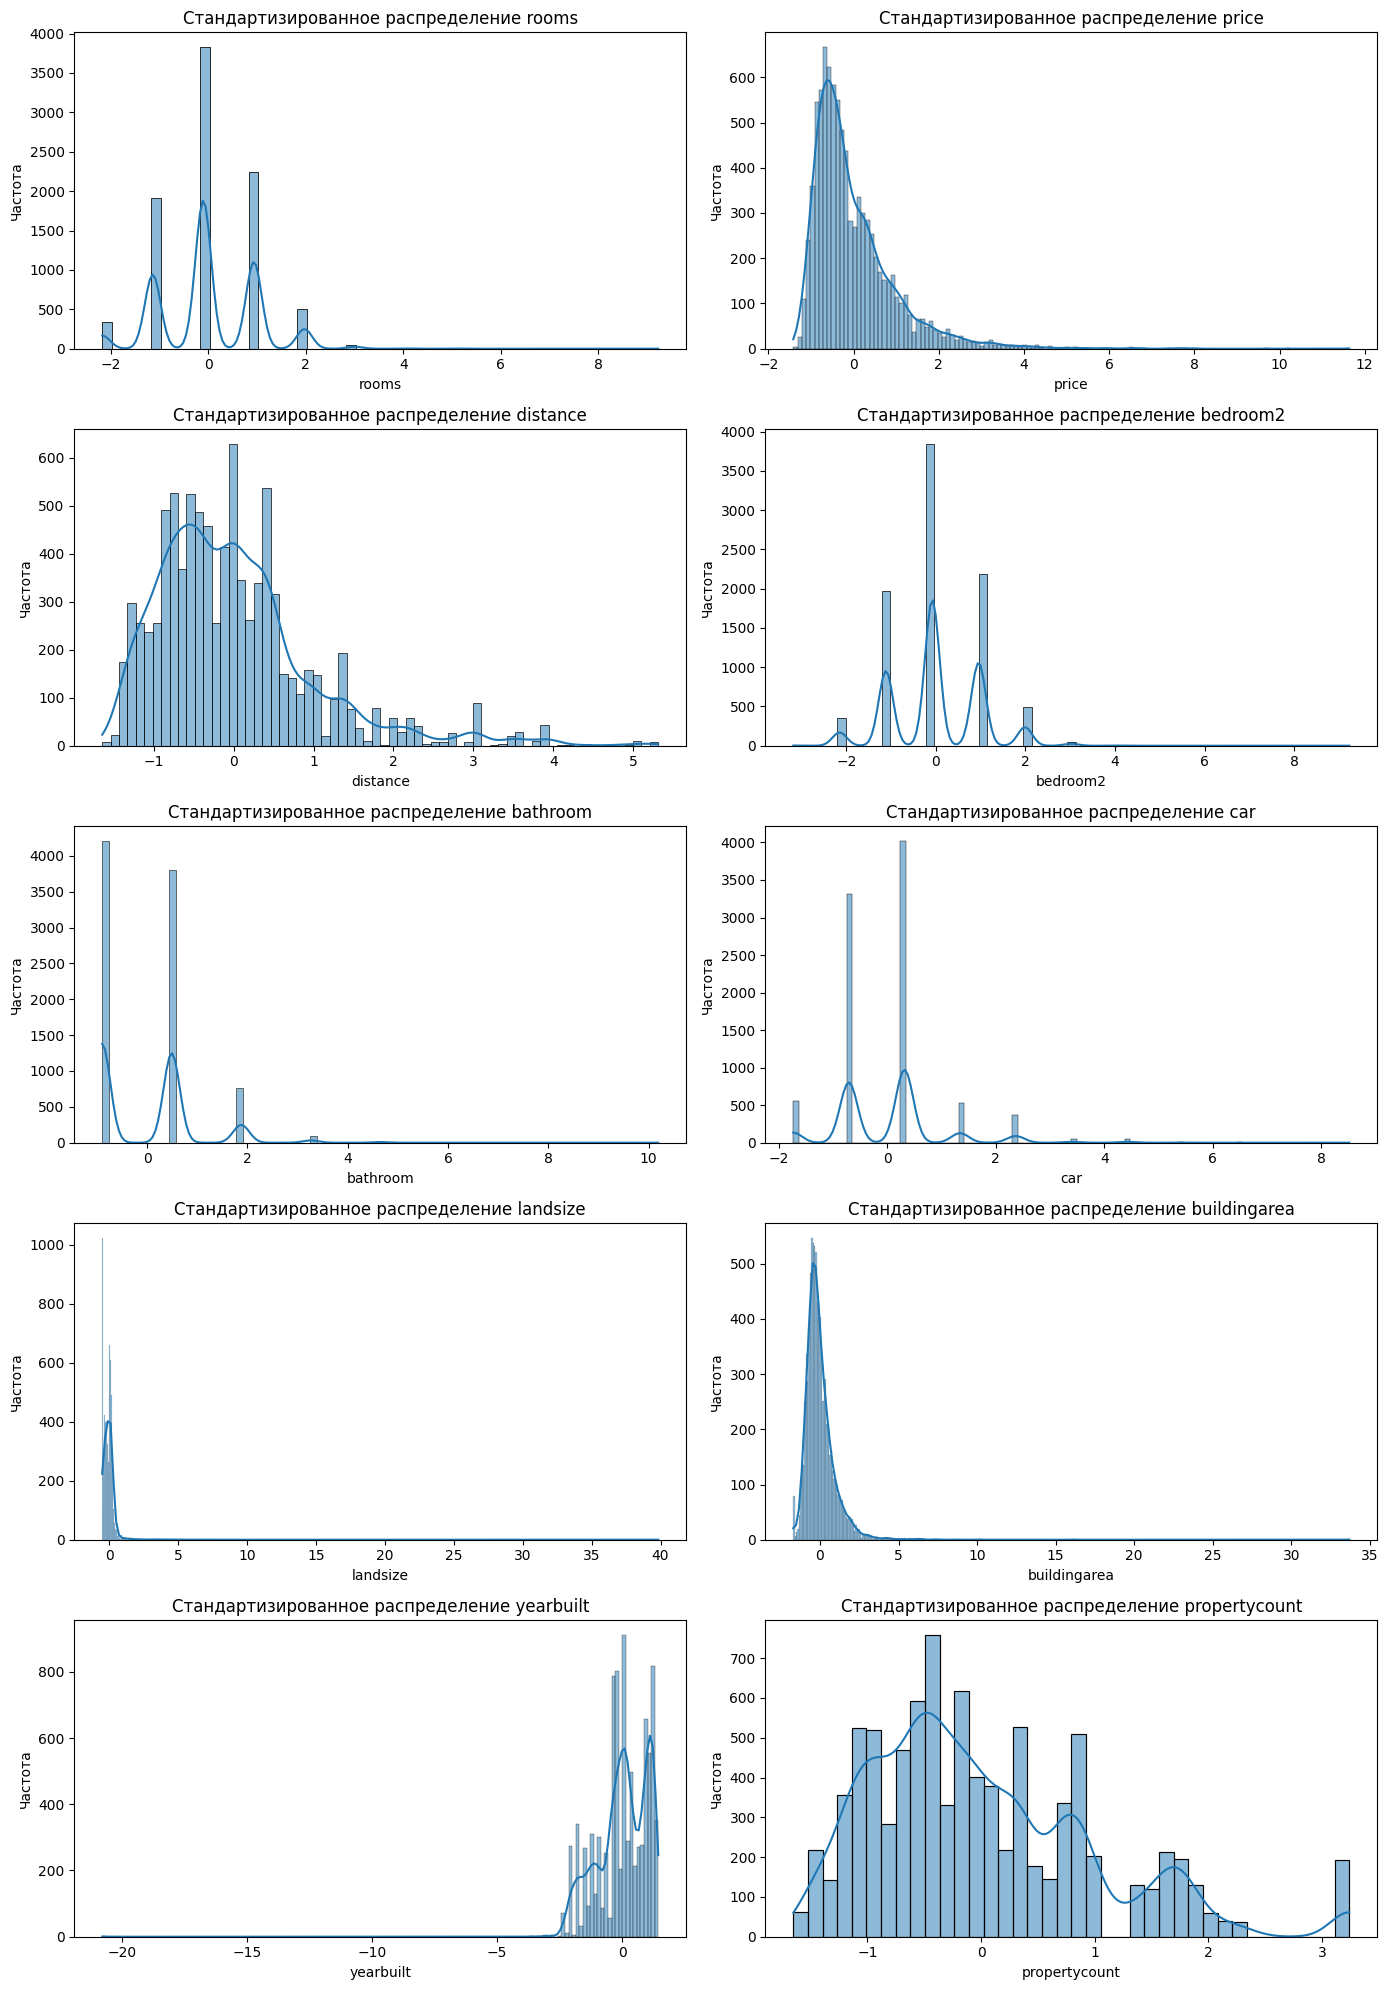

In [85]:
### BEGIN YOUR CODE
fig_standart_distributions, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(14, 20)
)

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(
        data=df_standart,
        x=feature,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Стандартизированное распределение {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Частота")

plt.tight_layout()

### END YOUR CODE

**Вопрос для размышления.** Запишите ответ в переменную `reflection_5_standardization`:

Изменилась ли форма распределений после стандартизации? Изменились ли среднее и стандартное отклонение? Почему?

In [86]:
### BEGIN YOUR CODE
reflection_5_standardization =  ("После стандартизации форма распределений числовых признаков не изменилась, поскольку стандартизация является линейным преобразованием данных. При этом среднее значение каждого признака стало близко к нулю, а стандартное отклонение стало близко к единице. Стандартизация изменяет масштаб признаков, но не изменяет характер их распределения.")
### END YOUR CODE

# Задание 3. Работа с категориальными признаками

## Шаг 1. Отбор категориальных признаков

Определите категориальные признаки датасета. Запишите их названия в список `cat_features`. После этого отделите от датафрейма `df_dropna` часть со всеми категориальными признаками.

**ВАЖНО**: не перезаписывайте `df_dropna`, запишите результат в переменную `df_cat`.

In [87]:
### BEGIN YOUR CODE
cat_features = [
    "suburb",
    "type",
    "method",
    "sellerg",
    "councilarea",
    "regionname",
    "postcode"
]

df_cat = df_dropna[cat_features].copy()
### END YOUR CODE

In [88]:
df_cat.head()

,suburb,type,method,sellerg,councilarea,regionname,postcode
2,Abbotsford,h,S,Biggin,Yarra City Council,Northern Metropolitan,3067.0
4,Abbotsford,h,SP,Biggin,Yarra City Council,Northern Metropolitan,3067.0
6,Abbotsford,h,VB,Nelson,Yarra City Council,Northern Metropolitan,3067.0
11,Abbotsford,h,S,Nelson,Yarra City Council,Northern Metropolitan,3067.0
14,Abbotsford,h,S,Nelson,Yarra City Council,Northern Metropolitan,3067.0


In [89]:
df_cat.nunique()

,0
suburb,315
type,3
method,5
sellerg,250
councilarea,33
regionname,8
postcode,194


## Шаг 2. Визуализация распределений категориальных признаков

Для каждого категориального признака визуализируйте частоту встречаемости каждой категории в виде столбчатой диаграммы. Подпишите оси и укажите название признака в заголовке. Сохраните Figure в переменную `fig_cat_distributions`.

Подсказка: используйте `value_counts()` для подсчёта частот и `sns.barplot` или `.plot(kind='bar')` для визуализации.

**Примечание**: если у признака более 20 категорий — отображайте только топ-20.

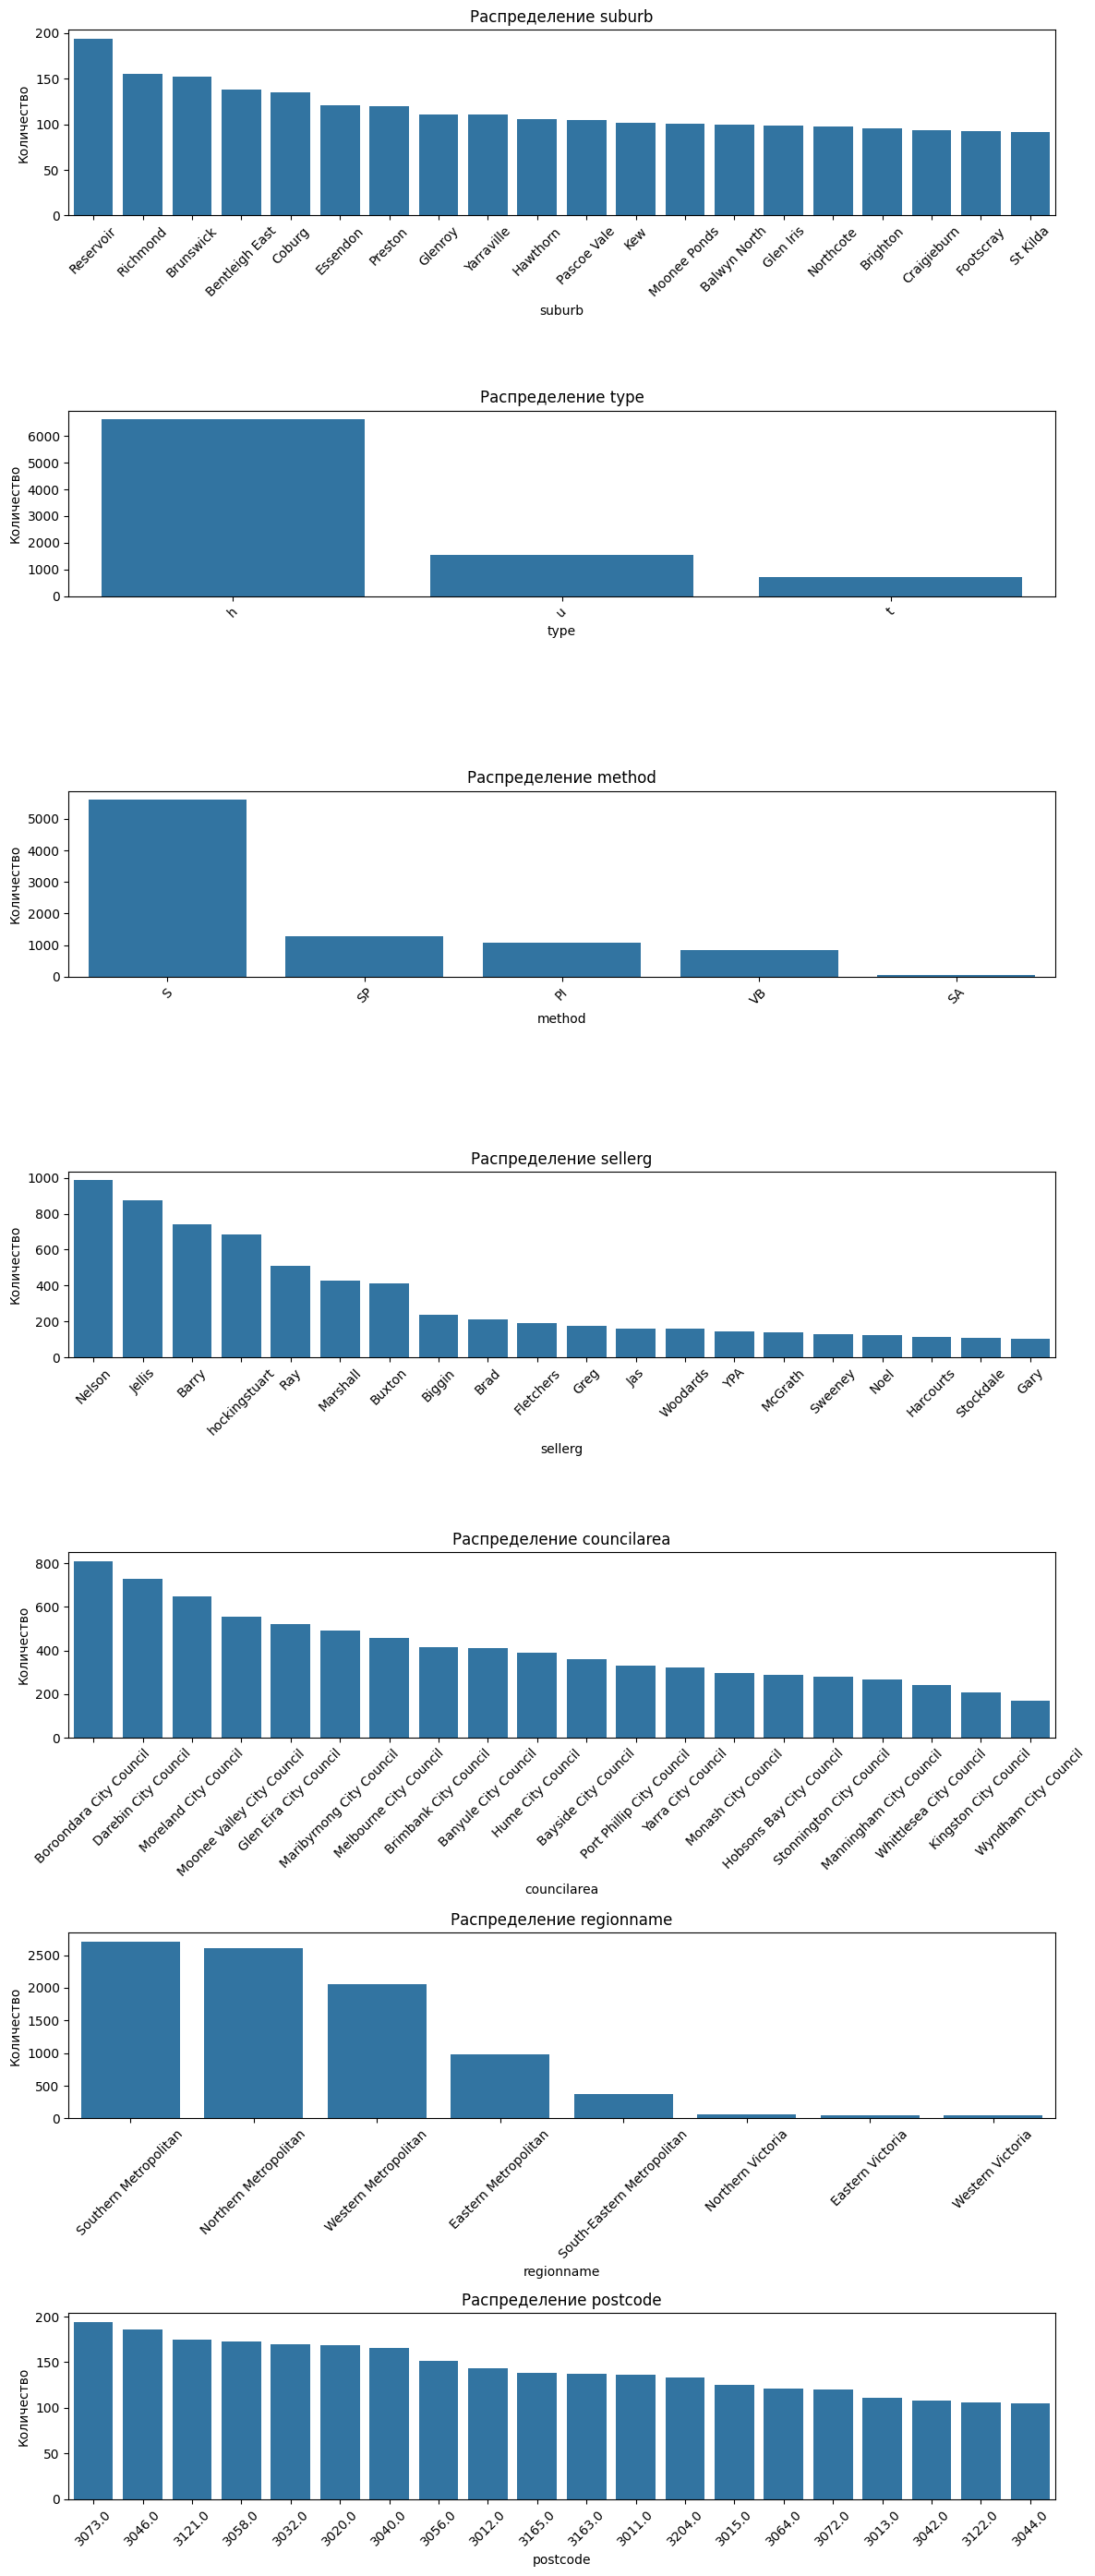

In [90]:
### BEGIN YOUR CODE
n = len(cat_features)

fig_cat_distributions, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(12, 4 * n)
)

if n == 1:
    axes = [axes]

for ax, feature in zip(axes, cat_features):
    counts = df_cat[feature].astype(str).value_counts().head(20)

    sns.barplot(
        x=counts.index,
        y=counts.values,
        ax=ax
    )

    ax.set_title(f"Распределение {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Количество")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

### END YOUR CODE

**Вопрос для размышления.** Запишите ответ в переменную `reflection_3_cat_imbalance`:

Есть ли в ваших категориальных признаках сильный дисбаланс (одна категория встречается значительно чаще других)? Для каких признаков это наблюдается и насколько выражен дисбаланс?

In [91]:
### BEGIN YOUR CODE
reflection_3_cat_imbalance = ("Категориальные признаки имеют разное количество уникальных значений. Некоторые признаки, такие как type, method и regionname, содержат небольшое число категорий, тогда как suburb и sellerg имеют значительно больше уникальных значений. Для некоторых признаков заметен дисбаланс: отдельные категории встречаются значительно чаще остальных. ")
### END YOUR CODE

## Шаг 3. One-hot encoding

Примените one-hot кодирование для ваших категориальных признаков. Подсказка: используйте `pandas.get_dummies(...)`.

**ВАЖНО**: не перезаписывайте `df_cat`, запишите результат в переменную `df_ohe`.

In [92]:
### BEGIN YOUR CODE

df_ohe = pd.get_dummies(
    df_cat.astype(str),
    prefix=cat_features,
    prefix_sep="_",
    dtype=int
)
### END YOUR CODE

In [93]:
df_ohe.head()

,suburb_Abbotsford,suburb_Aberfeldie,suburb_Airport West,suburb_Albanvale,suburb_Albert Park,suburb_Albion,suburb_Alphington,suburb_Altona,suburb_Altona Meadows,suburb_Altona North,...,postcode_3803.0,postcode_3805.0,postcode_3806.0,postcode_3807.0,postcode_3808.0,postcode_3809.0,postcode_3810.0,postcode_3910.0,postcode_3976.0,postcode_3977.0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [94]:
df_ohe.shape

(8887, 808)

**Вопрос для размышления.** Запишите ответ в переменную `reflection_3_ohe`:

Как изменилось число столбцов в датафрейме после one-hot кодирования? Чем это потенциально опасно при обучении модели?

In [95]:
### BEGIN YOUR CODE
reflection_3_ohe = ("One-hot преобразует категориальные признаки в набор бинарных столбцов, что позволяет использовать такие признаки в алгоритмах машинного обучения. Недостатком метода является увеличение размерности данных, особенно для признаков с большим количеством уникальных категорий")
### END YOUR CODE

# Задание 4. Поиск и удаление выбросов

В этом задании используем ранее полученные датафреймы `df_standart` и `df_ohe`.

Очистите данные от выбросов методом $3\sigma$, применив его к `df_standart`. Поскольку числовые данные уже стандартизированы, выбросом считается **объект** (строка датафрейма), у которого хотя бы один признак выходит за пределы интервала $(-3,\, 3)$, то есть $|z_{ij}| > 3$ хотя бы для одного признака $j$.

Алгоритм:
1. Найдите маску строк-выбросов в `df_standart`.
2. Удалите их из `df_standart`, сохраните результат в `df_standart_f`.
3. Используя ту же маску (по индексу), удалите соответствующие строки из `df_ohe`, сохраните в `df_ohe_f`.
4. Объедините `df_standart_f` и `df_ohe_f` по столбцам (`axis=1`), сохраните в `df_filtered`.

**ВАЖНО**: не перезаписывайте переменные `df_standart` и `df_ohe`.

In [96]:
### BEGIN YOUR CODE
# 1. Маска выбросов
outlier_mask = (df_standart.abs() > 3).any(axis=1)

# 2. Фильтрация числовых признаков
df_standart_f = df_standart.loc[~outlier_mask].copy()

# 3. Фильтрация категориальных признаков
df_ohe_f = df_ohe.loc[~outlier_mask].copy()

# 4. Объединение
df_filtered = pd.concat(
    [df_standart_f, df_ohe_f],
    axis=1
)


### END YOUR CODE

In [97]:
print("Было объектов:", len(df_standart))
print("Удалено выбросов:", outlier_mask.sum())
print("Осталось объектов:", len(df_standart_f))
print("Размер итоговой таблицы:", df_filtered.shape)

Было объектов: 8887
Удалено выбросов: 904
Осталось объектов: 7983
Размер итоговой таблицы: (7983, 818)


**Вопрос для размышления.** Запишите ответ в переменную `reflection_4_outliers`:

Сколько объектов было удалено как выбросы? Какой это процент от исходного датасета? Как вы считаете, стоит ли их удалять, или лучше было бы оставить — обоснуйте.

In [98]:
### BEGIN YOUR CODE
reflection_4_outliers =("Методом трех сигм было обнаружено 904 объекта с выбросами из 8887 объектов, что составляет примерно 10.2% данных. После удаления выбросов осталось 7983 объекта, что уменьшило влияние экстремальных значений на дальнейший анализ, однако перед удалением важно учитывать, что некоторые экстремальные значения могут быть реальными наблюдениями, а не ошибками в данных.")

### END YOUR CODE

### Дополнительное задание **. Поиск выбросов через расстояния до центроидов кластеров

**ВАЖНО**: не является обязательным, но даёт дополнительные баллы.

1. Выполните кластеризацию `df_standart` методом K-Means (`sklearn.cluster.KMeans`). Число кластеров выберите самостоятельно.
2. Для каждого объекта вычислите евклидово расстояние до центроида его кластера.
3. Внутри каждого кластера постройте распределение расстояний.
4. Отсеките выбросы по перцентилю (например, объекты дальше 95-го перцентиля). Обоснуйте выбор порога.

Сохраните итоговый датафрейм в переменную `df_filtered_kmeans`.

In [99]:
### BEGIN YOUR CODE


df_filtered_kmeans = None

### END YOUR CODE

---
## Финальные проверки

Перед отправкой работы убедитесь, что:
- ✅ Все ячейки выполнены (Run All)
- ✅ Все обязательные переменные созданы и имеют правильные имена
- ✅ Визуализации имеют подписи осей и заголовки
- ✅ Все тексты интерпретаций заполнены
- ✅ Код прокомментирован и читаем
- ✅ Ноутбук сохранен


In [100]:
def _is_defined(val):
    """Переменная считается заполненной, если она не None и не ..."""
    return val is not None and val is not ...

required_vars = [
    # Задание 1
    'Student_ID', 'df', 'columns', 'df_dropna',
    'reflection_1_missing', 'reflection_1_mean_median',
    # Задание 2
    'numeric_features', 'df_numeric',
    'fig_numeric_distributions',
    'corr_pearson', 'corr_spearman',
    'fig_heatmap_pearson', 'fig_heatmap_spearman',
    'reflection_3_pearson', 'reflection_3_difference',
    'means', 'medians', 'stds',
    'df_standart', 'fig_standart_distributions',
    'reflection_5_standardization',
    # Задание 3
    'cat_features', 'df_cat',
    'fig_cat_distributions',
    'reflection_3_cat_imbalance',
    'df_ohe',
    'reflection_3_ohe',
    # Задание 4
    'df_standart_f', 'df_ohe_f', 'df_filtered',
    'reflection_4_outliers',
]

bonus_vars = [
    'df_fillna',           # Доп. задание *
    'df_filtered_kmeans',  # Доп. задание **
]

print('=' * 60)
print('ПРОВЕРКА ОБЯЗАТЕЛЬНЫХ ПЕРЕМЕННЫХ:')
print('=' * 60)
all_ok = True
for var in required_vars:
    if var in globals() and _is_defined(globals()[var]):
        print(f'  ✓ {var}')
    else:
        print(f'  ✗ {var} — НЕ ОПРЕДЕЛЕНА!')
        all_ok = False

print()
print('=' * 60)
print('ПРОВЕРКА БОНУСНЫХ ПЕРЕМЕННЫХ:')
print('=' * 60)
for var in bonus_vars:
    if var in globals() and _is_defined(globals()[var]):
        print(f'  ✓ {var}')
    else:
        print(f'  ○ {var} — не выполнено (бонус)')

if all_ok:
    print('\n✅ Все обязательные переменные определены. Работа готова к сдаче!')
else:
    print('\n⚠️  Есть незаполненные обязательные переменные. Проверьте ваш код.')


ПРОВЕРКА ОБЯЗАТЕЛЬНЫХ ПЕРЕМЕННЫХ:
  ✓ Student_ID
  ✓ df
  ✓ columns
  ✓ df_dropna
  ✓ reflection_1_missing
  ✓ reflection_1_mean_median
  ✓ numeric_features
  ✓ df_numeric
  ✓ fig_numeric_distributions
  ✓ corr_pearson
  ✓ corr_spearman
  ✓ fig_heatmap_pearson
  ✓ fig_heatmap_spearman
  ✓ reflection_3_pearson
  ✓ reflection_3_difference
  ✓ means
  ✓ medians
  ✓ stds
  ✓ df_standart
  ✓ fig_standart_distributions
  ✓ reflection_5_standardization
  ✓ cat_features
  ✓ df_cat
  ✓ fig_cat_distributions
  ✓ reflection_3_cat_imbalance
  ✓ df_ohe
  ✓ reflection_3_ohe
  ✓ df_standart_f
  ✓ df_ohe_f
  ✓ df_filtered
  ✓ reflection_4_outliers

ПРОВЕРКА БОНУСНЫХ ПЕРЕМЕННЫХ:
  ✓ df_fillna
  ○ df_filtered_kmeans — не выполнено (бонус)

✅ Все обязательные переменные определены. Работа готова к сдаче!
